In [44]:
# !unzip pedestrians.zip -d train
# !unzip "Test images-pedestrians.zip" -d test/
import scipy
import numpy as np
import matplotlib.pyplot as plt
import cv2

# HOG

In [ ]:
from typing import Tuple


class HOG():
    def __init__(self):
        pass

    def get_max_from_channels(self, Img: np.ndarray):
        if Img.ndim == 2:
            # Already a single-channel image (e.g., grayscale or processed gradient)
            return Img

        if Img.shape[2] != 3:
            raise ValueError(f"Expected 3 channels, got shape {Img.shape}")

        output = np.zeros(Img.shape[:2])

        max_0 = np.logical_and(
            Img[:, :, 1] < Img[:, :, 0],
            Img[:, :, 2] < Img[:, :, 0],
        )
        output[max_0] = Img[:, :, 0][max_0]

        max_1 = np.logical_and(
            Img[:, :, 0] < Img[:, :, 1],
            Img[:, :, 2] < Img[:, :, 1],
        )
        output[max_1] = Img[:, :, 1][max_1]

        max_2 = np.logical_and(
            Img[:, :, 0] < Img[:, :, 2],
            Img[:, :, 1] < Img[:, :, 2],
        )
        output[max_2] = Img[:, :, 2][max_2]

        return output

    def get_max_grad_mag_angle(self, Img: cv2.Mat):

        dx = scipy.ndimage.convolve1d(np.int32(Img), np.array([-1, 0, 1]), 1).astype(float)
        dy = scipy.ndimage.convolve1d(np.int32(Img), np.array([-1, 0, 1]), 0).astype(float)

        magnitude = np.sqrt(np.square(dx) + np.square(dy))
        angle = np.atan(dy, dx)

        max_magnitude = self.get_max_from_channels(magnitude)
        max_angle = self.get_max_from_channels(angle)

        return (max_magnitude, max_angle)
    
    def get_block_histogram(self, Imgs: Tuple[cv2.Mat, cv2.Mat], cellSize = 8):
        
        X_cell_quantity= np.int32(Imgs[0].shape[0]/cellSize)
        Y_cell_quantity = np.int32(Imgs[0].shape[1]/cellSize)

        hitogram_container = np.ndarray([X_cell_quantity*Y_cell_quantity, cellSize*cellSize])




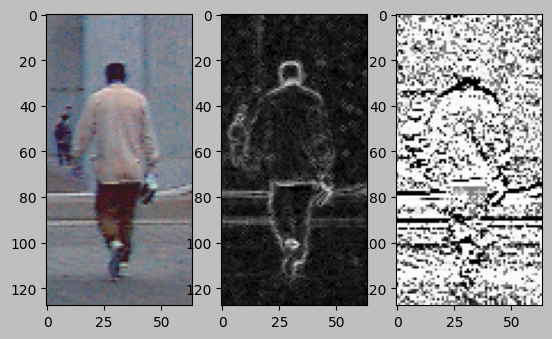

In [46]:
example_human = cv2.imread("train/pos/per00001.ppm")
hog = HOG()


plt.style.use('grayscale')
fig, axes = plt.subplots(1, 3)
axes[0].imshow(example_human)
axes[1].imshow(hog.get_max_grad_mag_angle(example_human)[0])
axes[2].imshow(hog.get_max_grad_mag_angle(example_human)[1])